<a href="https://colab.research.google.com/github/kkeenchs/01204466-Deep-learning-final-project/blob/main/%E0%B8%B4brain_tumor_detection_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Splitting + transform data

In [1]:
import os, sys, math, time, random, json
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


device(type='cuda')

In [2]:
import kagglehub

path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Path to dataset files:", path)
DATA_DIR = Path("data/brain_tumor")

IMG_SIZE   = 224
TEST_SPLIT = 0.2

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-mri-images-for-brain-tumor-detection


In [3]:

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


In [4]:
full_ds = datasets.ImageFolder(path+"/brain_tumor_dataset")
num_total = len(full_ds)
n_test  = int(TEST_SPLIT * num_total)
n_train = num_total - n_test

train_ds, test_ds = random_split(
    full_ds,
    [n_train, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

train_ds.dataset.transform = train_tfms
test_ds.dataset.transform = eval_tfms

class_names = full_ds.classes
num_classes = len(class_names)

print("Classes:", class_names)
print(f"Train/Test sizes: {len(train_ds)}/{len(test_ds)}")


Classes: ['no', 'yes']
Train/Test sizes: 203/50


## Models: **HandMadeCNN**

In [5]:
class CNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (IMG_SIZE//8) * (IMG_SIZE//8), 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


### hyperparameter adjust

In [6]:
BATCH_SIZE = 16
EPOCHS     = 10
LR         = 1e-5

In [7]:
pin = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin)

len(train_loader), len(test_loader)


(13, 4)

### loss function + optimizer + scheduler

In [8]:
model = CNN(num_classes)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

sum(p.numel() for p in model.parameters()), sum(p.numel() for p in model.parameters() if p.requires_grad)


(12869634, 12869634)

### training function

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device=DEVICE):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="train", leave=False)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

    for imgs, labels in pbar:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        autocast_device = "cuda" if device.type == "cuda" else "cpu"
        with torch.amp.autocast(autocast_device, enabled=True):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        if device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{(correct/total):.4f}")

    epoch_loss = running_loss / total if total else 0.0
    epoch_acc = correct / total if total else 0.0
    return epoch_loss, epoch_acc


### training loop

In [10]:

history = {"train_loss": [], "train_acc": []}
best_val = float("inf")

for epoch in range(1, EPOCHS+1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device=DEVICE)
    scheduler.step(tr_loss)
    print(f"Epoch {epoch}/{EPOCHS} | train: loss={tr_loss:.4f}, acc={tr_acc:.4f}")
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)


print("Training complete.")



Epoch 1/10


train:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 1/10 | train: loss=0.5305, acc=0.7635

Epoch 2/10


train:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 2/10 | train: loss=0.4040, acc=0.8227

Epoch 3/10


...

Epoch 8/10 | train: loss=0.1065, acc=0.9901

Epoch 9/10


train:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 9/10 | train: loss=0.0904, acc=0.9901

Epoch 10/10


train:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 10/10 | train: loss=0.0784, acc=0.9951
Training complete.


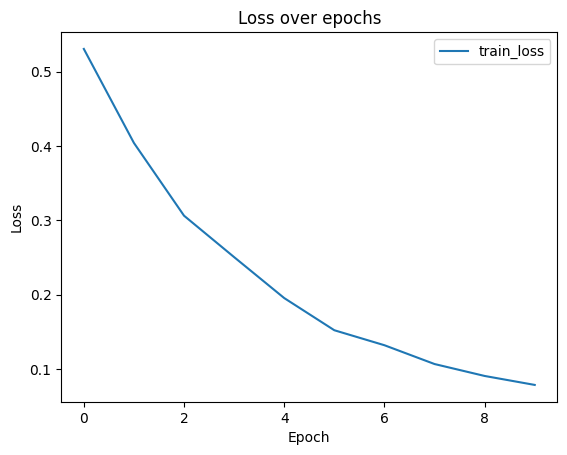

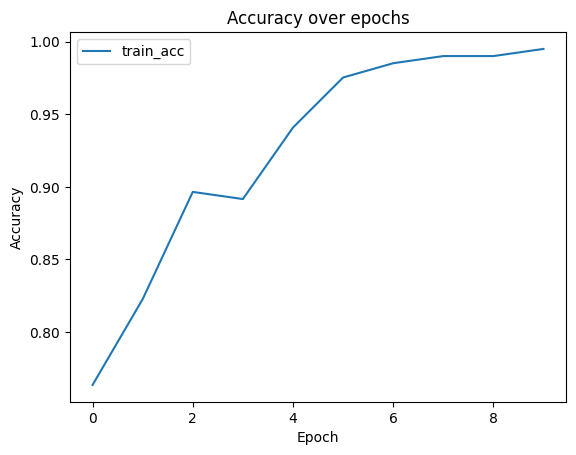

In [11]:
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss over epochs"); plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_acc"], label="train_acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy over epochs"); plt.legend()
plt.show()


### testing on test set

test:   0%|          | 0/4 [00:00<?, ?it/s]

Test Accuracy: 0.8200
Confusion Matrix:
 [[12  4]
 [ 5 29]]
              precision    recall  f1-score   support

          no     0.7059    0.7500    0.7273        16
         yes     0.8788    0.8529    0.8657        34

    accuracy                         0.8200        50
   macro avg     0.7923    0.8015    0.7965        50
weighted avg     0.8235    0.8200    0.8214        50



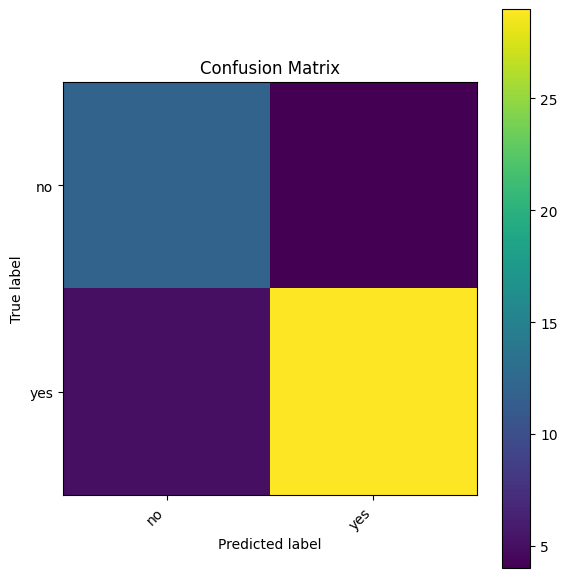

In [12]:
@torch.no_grad()
def predict_logits(model, loader, device=DEVICE):
    model.eval()
    all_logits = []
    all_labels = []
    for imgs, labels in tqdm(loader, desc="test", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        logits = model(imgs)
        all_logits.append(logits.cpu())
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)

if Path("best_model.pth").exists():
    checkpoint = torch.load("best_model.pth", map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state"])

logits, y_true = predict_logits(model, test_loader, device=DEVICE)
y_pred = logits.argmax(dim=1)

test_acc = (y_pred == y_true).float().mean().item()
print(f"Test Accuracy: {test_acc:.4f}")

cm = confusion_matrix(y_true.numpy(), y_pred.numpy())
print("Confusion Matrix:\n", cm)

report = classification_report(y_true.numpy(), y_pred.numpy(), target_names=class_names, digits=4)
print(report)

plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)
plt.ylabel("True label"); plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


### DEMO

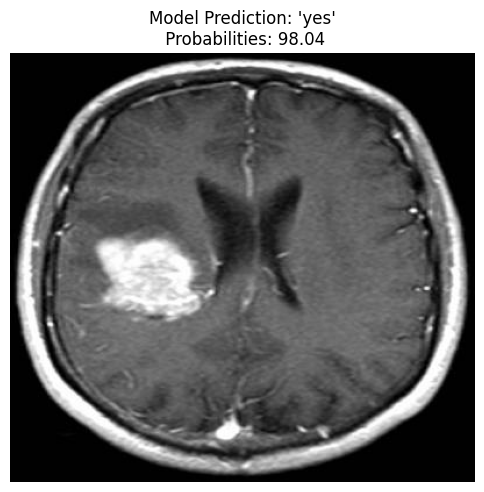

In [13]:
# Demo
from PIL import Image

def infer_image(path, model, class_names, device=DEVICE):
    img = Image.open(path).convert("RGB")
    tfm = eval_tfms
    x = tfm(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy().squeeze()
    pred_idx = int(np.argmax(probs))
    return class_names[pred_idx], probs

demo_path = "/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/yes/Y11.jpg" # <-- choose picture path for demo
pred, probs = infer_image(demo_path, model, class_names)
max_prob = probs.max()
plt.figure(figsize=(6,6))
plt.imshow(Image.open(demo_path))
plt.title(f"Model Prediction: '{pred}'\n Probabilities: {max_prob*100:.2f}")
plt.axis('off')
plt.show()

In [14]:
%pip install onnx

In [15]:
dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)
torch.onnx.export(
    model,
    dummy_input,
    "cnn_model.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11
)

/tmp/ipython-input-1612571688.py:2: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
